<a href="https://colab.research.google.com/github/alexanderson522/INFO648/blob/main/Homeworks/Homework_3/INFO648_Problem_Set_3_Alex_Anderson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part A - Windsorization (Outlier Handling)

In [38]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [ ]:
#read in data
df=pd.read_csv('/content/cps_with_education.csv')
df.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
0,0,2020,40,0.0,63,2,23,Some College
1,1,2020,999,0.0,67,1,23,Some College
2,2,2020,48,654.0,64,1,23,Some College
3,3,2020,999,0.0,71,2,23,Less than HS
4,4,2020,44,0.0,54,2,23,Some College


Looking at the initial view of the data set and the first creation of our Tukey summary, it is apparent we have some invalid rows in the dataset. Weekly hours worked cannot exceed 168 and weekly earnings (presumably) cannot be 0 or 999999.99, so we will clean the data of these rows to get a better picture.

Since this is the same data set as the previous problem set, there are invalid rows present in the data. We will clean the data by:
- removing all rows where earnings are 999999.99 or non-positive
- remove rows where hours worked exceeds total hours in a week (168 hours)
- Keep only observations from 2024 and 2025

In [5]:
df_clean=df[(df["EARNWEEK2"]<999999)&
    (df["EARNWEEK2"] > 0)].copy()
df_clean=df_clean[df_clean['UHRSWORKT']<168].copy() #only 168 hours in a week
df_clean=df_clean[(df_clean['YEAR']==2024) | (df_clean['YEAR']==2025)].copy()
df_clean.head()


,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
3076326,3076326,2024,40,520.0,36,1,1,Some College
3076330,3076330,2024,40,700.0,23,2,1,Some College
3076332,3076332,2024,35,516.0,64,2,1,Some College
3076333,3076333,2024,40,720.0,57,2,1,Some College
3076334,3076334,2024,12,220.0,69,1,1,Some College


In [28]:
#Create 4 groups: Men-2024, Men-2025, Women-2024, Women-2025
men_2024=df_clean[(df_clean['SEX']==1) & (df_clean['YEAR']==2024)].copy()
men_2025=df_clean[(df_clean['SEX']==1) & (df_clean['YEAR']==2025)].copy()
women_2024=df_clean[(df_clean['SEX']==2) & (df_clean['YEAR']==2024)].copy()
women_2025=df_clean[(df_clean['SEX']==2) & (df_clean['YEAR']==2025)].copy()


In [29]:
men_2024.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
3076326,3076326,2024,40,520.0,36,1,1,Some College
3076334,3076334,2024,12,220.0,69,1,1,Some College
3076344,3076344,2024,40,2880.0,64,1,1,Graduate / Professional
3076347,3076347,2024,60,1730.0,58,1,1,Some College
3076349,3076349,2024,40,880.0,47,1,1,Bachelor's


In [30]:
men_2025.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
4369979,4369979,2025,40,760.0,65,1,5,Some College
4369981,4369981,2025,38,1650.0,41,1,2,Master's
4370050,4370050,2025,40,962.0,36,1,1,Graduate / Professional
4370063,4370063,2025,40,660.0,26,1,5,Associate's
4370069,4370069,2025,36,1690.0,36,1,42,Some College


In [31]:
women_2024.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
3076330,3076330,2024,40,700.0,23,2,1,Some College
3076332,3076332,2024,35,516.0,64,2,1,Some College
3076333,3076333,2024,40,720.0,57,2,1,Some College
3076345,3076345,2024,40,654.0,60,2,1,Associate's
3076346,3076346,2024,20,300.0,18,2,1,Some College


In [32]:
women_2025.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
4369980,4369980,2025,40,734.0,59,2,5,Some College
4369985,4369985,2025,30,570.0,33,2,8,Bachelor's
4369992,4369992,2025,40,1046.0,36,2,6,Master's
4370049,4370049,2025,10,480.0,36,2,1,Master's
4370064,4370064,2025,35,466.0,25,2,5,Associate's


In [33]:
#Windsorization; find 95th percentile cutoff for each of the four groups
men_2024_cutoff=men_2024['EARNWEEK2'].quantile(0.95)
men_2025_cutoff=men_2025['EARNWEEK2'].quantile(0.95)
women_2024_cutoff=women_2024['EARNWEEK2'].quantile(0.95)
women_2025_cutoff=women_2025['EARNWEEK2'].quantile(0.95)

In [36]:
#Create a new column called EARNWEEK2_w95 using cutoff value.
#If the EARNWEEK2 value at the location is greater than the cutoff value, change the EARNWEEK2_w95 columns value
men_2024['EARNWEEK2_w95']=men_2024['EARNWEEK2']
men_2024.loc[men_2024['EARNWEEK2']>men_2024_cutoff,'EARNWEEK2_w95']=men_2024_cutoff

men_2025['EARNWEEK2_w95']=men_2025['EARNWEEK2']
men_2025.loc[men_2025['EARNWEEK2']>men_2025_cutoff,'EARNWEEK2_w95']=men_2025_cutoff

women_2024['EARNWEEK2_w95']=women_2024['EARNWEEK2']
women_2024.loc[women_2024['EARNWEEK2']>women_2024_cutoff,'EARNWEEK2_w95']=women_2024_cutoff

women_2025['EARNWEEK2_w95']=women_2025['EARNWEEK2']
women_2025.loc[women_2025['EARNWEEK2']>women_2025_cutoff,'EARNWEEK2_w95']=women_2025_cutoff

In [43]:
# Create a DataFrame to display the cutoffs and winsorized sample sizes

# Calculate the number of winsorized rows for each group
men_2024_winsorized_count = (men_2024['EARNWEEK2'] > men_2024_cutoff).sum()
men_2025_winsorized_count = (men_2025['EARNWEEK2'] > men_2025_cutoff).sum()
women_2024_winsorized_count = (women_2024['EARNWEEK2'] > women_2024_cutoff).sum()
women_2025_winsorized_count = (women_2025['EARNWEEK2'] > women_2025_cutoff).sum()

group_data = {
    'Group': ['Men-2024', 'Men-2025', 'Women-2024', 'Women-2025'],
    'Cutoff': [men_2024_cutoff, men_2025_cutoff, women_2024_cutoff, women_2025_cutoff],
    'Sample Size': [len(men_2024), len(men_2025), len(women_2024), len(women_2025)],
    'Winsorized Rows': [
        men_2024_winsorized_count,
        men_2025_winsorized_count,
        women_2024_winsorized_count,
        women_2025_winsorized_count
    ]
}

summary_df = pd.DataFrame(group_data)
display(summary_df)

,Group,Cutoff,Sample Size,Winsorized Rows
0,Men-2024,3660.0,63274,3116
1,Men-2025,3880.0,53157,2656
2,Women-2024,2880.0,60949,2946
3,Women-2025,2980.0,51170,2536


The Men-2024 cutoff is 3660 and the sample size is 63,274, with 3116 rows being winsorized. The Men-2025 cutoff is 3880 and the sample size is 53,157, with 2656 rows being winsorized. The Women-2024 cutoff is 2880 and sample size is 60,949, with 2946 rows being winsorized. The Women-2025 cutoff is 2980 and sample size is 51,170, with 2536 rows being winsorized.

#Part B - Confidence Intervals for Population Mean Earnings

In [39]:
#Compute mean and standard deviation of each group
men_2024_mean=men_2024['EARNWEEK2_w95'].mean()
men_2024_std=men_2024['EARNWEEK2_w95'].std()
men_2025_mean=men_2025['EARNWEEK2_w95'].mean()
men_2025_std=men_2025['EARNWEEK2_w95'].std()
women_2024_mean=women_2024['EARNWEEK2_w95'].mean()
women_2024_std=women_2024['EARNWEEK2_w95'].std()
women_2025_mean=women_2025['EARNWEEK2_w95'].mean()
women_2025_std=women_2025['EARNWEEK2_w95'].std()

In [41]:
#compute 95% CI for each group
z=norm.ppf(1-0.025)

men_2024_ci_lower=men_2024_mean-z*(men_2024_std/np.sqrt(len(men_2024)))
men_2024_ci_upper=men_2024_mean+z*(men_2024_std/np.sqrt(len(men_2024)))

men_2025_ci_lower=men_2025_mean-z*(men_2025_std/np.sqrt(len(men_2025)))
men_2025_ci_upper=men_2025_mean+z*(men_2025_std/np.sqrt(len(men_2025)))

women_2024_ci_lower=women_2024_mean-z*(women_2024_std/np.sqrt(len(women_2024)))
women_2024_ci_upper=women_2024_mean+z*(women_2024_std/np.sqrt(len(women_2024)))

women_2025_ci_lower=women_2025_mean-z*(women_2025_std/np.sqrt(len(women_2025)))
women_2025_ci_upper=women_2025_mean+z*(women_2025_std/np.sqrt(len(women_2025)))

In [44]:
#Display confidence interval for each group
ci_data = {
    'Group': ['Men-2024', 'Men-2025', 'Women-2024', 'Women-2025'],
    'Conf. Int. Lower': [men_2024_ci_lower, men_2025_ci_lower, women_2024_ci_lower, women_2025_ci_lower],
    'Conf. Int. Upper': [men_2024_ci_upper, men_2025_ci_upper, women_2024_ci_upper, women_2025_ci_upper],
}

summary_df = pd.DataFrame(ci_data)
display(summary_df)

,Group,Conf. Int. Lower,Conf. Int. Upper
0,Men-2024,1412.607246,1426.797761
1,Men-2025,1487.201432,1503.832284
2,Women-2024,1097.480629,1108.903523
3,Women-2025,1137.105934,1150.049728


These intervals mean that we are 95% confident that the population's mean earnings for each group falls between the listed lower and upper interval:
- Men-2024: (1412.61,1426.80)
- Men-2025: (1487.20, 1503.83)
- Women-2024: (1097.48, 1108.90)
- Women-2025: (1137.11, 1150.05)

When comparing the different years within both men and women, we can see that there is no overlap in the confidence intervals between 2024 and 2025 for each group. In fact, the upper limit for 2024 is less than the lower limit for 2025 for both men and women. This strongly suggests that the mean earnings for 2025 men/women is higher than their 2024 counterpart.

#Part C - Compare Earnings Distributions

In [ ]:
#find mean, median, standard devation for college_grads
print(f"Mean: {college_grads['EARNWEEK2'].mean()}")
print(f"Median: {college_grads['EARNWEEK2'].median()}")
print(f"Standard Deviation: {college_grads['EARNWEEK2'].std()}")

Mean: 1129.840932047175
Median: 962.0
Standard Deviation: 862.1550970871148


In [ ]:
#find mean, median, standard devation for grad_students
print(f"Mean: {grad_students['EARNWEEK2'].mean()}")
print(f"Median: {grad_students['EARNWEEK2'].median()}")
print(f"Standard Deviation: {grad_students['EARNWEEK2'].std()}")

Mean: 1658.759282219462
Median: 1350.0
Standard Deviation: 1430.39560648995


In [ ]:
#find tukey summary for college_grads
college_grads['EARNWEEK2'].quantile([0,0.25,0.5,0.75,1])

,EARNWEEK2
0.00,4.00
0.25,674.00
0.50,962.00
0.75,1390.00
1.00,13258.23


In [ ]:
#fnd tukey summary for grad_students
grad_students['EARNWEEK2'].quantile([0,0.25,0.5,0.75,1])

,EARNWEEK2
0.00,4.00
0.25,880.00
0.50,1350.00
0.75,2020.00
1.00,13258.23


In [ ]:
college_grads['UHRSWORKT'].quantile([0,0.25,0.5,0.75,1])

,UHRSWORKT
0.00,0.0
0.25,40.0
0.50,40.0
0.75,40.0
1.00,156.0


In [ ]:
grad_students['UHRSWORKT'].quantile([0,0.25,0.5,0.75,1])

,UHRSWORKT
0.00,0.0
0.25,40.0
0.50,40.0
0.75,40.0
1.00,140.0


/tmp/ipykernel_12293/1801475715.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([college_grads['EARNWEEK2'], grad_students['EARNWEEK2']], labels=["Bachelor's", "Master's"])


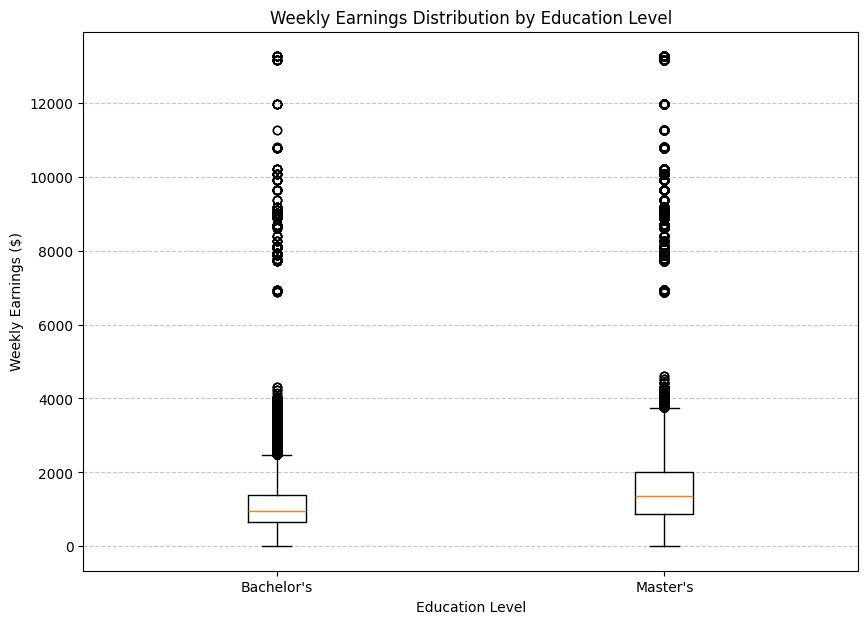

In [ ]:
# Create box plots for college_grads and grad_students on the same plot
plt.figure(figsize=(10, 7))
plt.boxplot([college_grads['EARNWEEK2'], grad_students['EARNWEEK2']], labels=["Bachelor's", "Master's"])
plt.title('Weekly Earnings Distribution by Education Level')
plt.ylabel('Weekly Earnings ($)')
plt.xlabel('Education Level')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The typical earnings for a Master's recipient is noticeably higher than that of a Bachelor's recipient. This difference can be seen by using both median (college grads 962 to Master's grad's 1350) and mean earnings (college grads 1125 to Master's grad's 1654). While Master's recipients typically have higher earnings than their Bachelor's counterparts, they also have higher variability in their earnings. Bachelor's earners have an IQR of 716 while Master's earners have an IQR of 1140. Bachelor's earners also have a standard deviation of 862 while Master's earners have a standard deviation of 1430, once again showing that Master's earners have a much wider distribution of weekly earnings.

#Part D - Correlation between Hours and Earnings

In [ ]:
#correlation of Hours Worked and Weekly Earnings for college_grads
college_grads[['UHRSWORKT', 'EARNWEEK2']].corr()

,UHRSWORKT,EARNWEEK2
UHRSWORKT,1.000000,0.342031
EARNWEEK2,0.342031,1.000000


In [ ]:
#correlation of Hours Worked and Weekly Earnings for college_grads
grad_students[['UHRSWORKT', 'EARNWEEK2']].corr()

,UHRSWORKT,EARNWEEK2
UHRSWORKT,1.000000,0.268961
EARNWEEK2,0.268961,1.000000


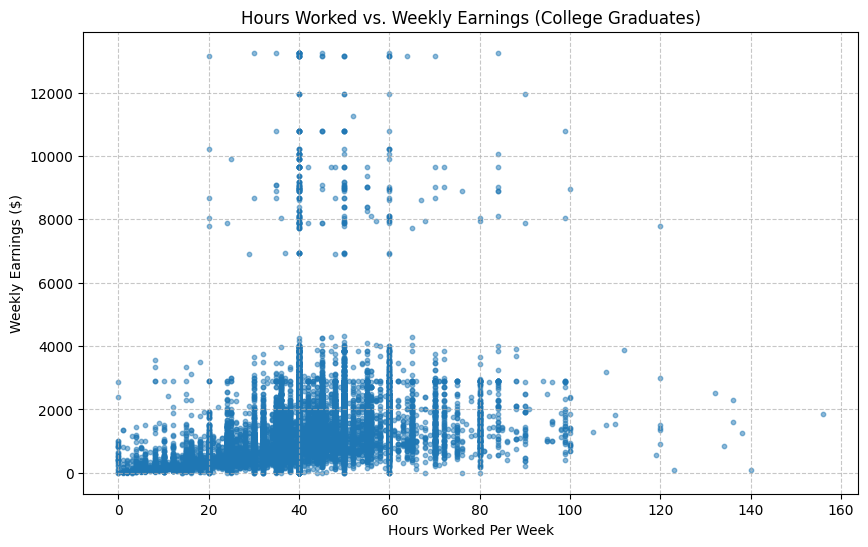

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(college_grads['UHRSWORKT'], college_grads['EARNWEEK2'], alpha=0.5, s=10)
plt.title('Hours Worked vs. Weekly Earnings (College Graduates)')
plt.xlabel('Hours Worked Per Week')
plt.ylabel('Weekly Earnings ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

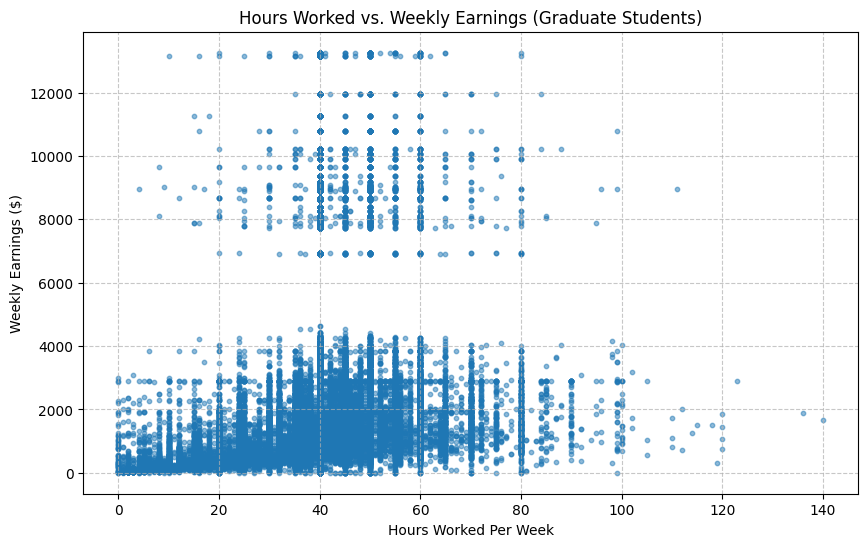

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(grad_students['UHRSWORKT'], grad_students['EARNWEEK2'], alpha=0.5, s=10)
plt.title('Hours Worked vs. Weekly Earnings (Graduate Students)')
plt.xlabel('Hours Worked Per Week')
plt.ylabel('Weekly Earnings ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Looking at the correlation between hours worked and weekly earnings, neither college grads (0.34) nor grad students (0.27) have a particularly strong correlation between the two data points. We can see in the plots that it does explain *some* of the variance, especially as we go from 0 to 40 hours worked, but there is significant variability in earnings and a high number of outliers, even at the same number of hours worked.

#Part E - Reflection

When comparing earnings across education groups, median (and IQR) were the most useful statistics for comparing earnings across education groups. Both college grads and grad students had very large outliers that skewed the data, making the mean/standard deviation less of an effective statistic in this scenario. This can be seen by the difference in mean and median for both college grads (1129 mean vs. 962 median) and grad students (1659 mean vs. 1350 median). The correlation between hours worked weekly earnings was also too low for both education groups to properly tell the story of each group's earnings.